# Human Feedback

In [3]:
# import your LLM model
from langchain_ollama import ChatOllama
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image,display,Markdown
from typing_extensions import Literal
from pydantic import BaseModel,Field
from langchain_core.messages import AIMessage,HumanMessage,SystemMessage
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
llm = ChatOllama(model='llama3.1:8b')
results = llm.invoke('Hello my name is Hanif')
print(results)

content='Nice to meet you, Hanif! Is there something I can help you with or would you like to chat for a bit?' additional_kwargs={} response_metadata={'model': 'llama3.1:8b', 'created_at': '2026-01-02T09:21:37.4488634Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1905174600, 'load_duration': 24994800, 'prompt_eval_count': 16, 'prompt_eval_duration': 85525500, 'eval_count': 27, 'eval_duration': 1794059400, 'model_name': 'llama3.1:8b'} id='run--ff6f5781-d63f-4adc-8e64-c98910e9a835-0' usage_metadata={'input_tokens': 16, 'output_tokens': 27, 'total_tokens': 43}


In [5]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper
from langchain_community.tools import TavilySearchResults
from dotenv import load_dotenv
load_dotenv()
import os
tavily_api_key = os.getenv("TAVILY_API_KEY")
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=1000)
arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
api_wrapper_wikipedia = WikipediaAPIWrapper(top_k_results=2,doc_content_chars_max=10000)
wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wikipedia)
tavily_search_engine = TavilySearchResults(tavily_api_key=tavily_api_key,top_k=2)
tools = [arxiv,wiki,tavily_search_engine]
llm_with_tools = llm.bind_tools(tools)

In [ ]:
sys_message = SystemMessage(content="You are helpful AI assistant for investment analyst who is working in mining company.")

def human_feedback(state:MessagesState):
    pass

def assistant(state:MessagesState):
    return {"messages": [llm_with_tools.invoke([sys_message] + state["messages"])]}

builder = StateGraph(MessagesState)

builder.add_node("assistant",assistant)
builder.add_node("human_feedback",human_feedback)
builder.add_node("tools",ToolNode(tools))

builder.add_edge(START,"human_feedback")
builder.add_edge("human_feedback","assistant")
builder.add_conditional_edges(
    "assistant",
    tools_condition
)
builder.add_edge("tools","human_feedback")

memory = MemorySaver()

graph = builder.compile(interrupt_before=['human_feedback'],checkpointer=memory)

In [27]:
mermaid_code = graph.get_graph().draw_mermaid()
with open("human_feedback.mmd", "w") as f:
    f.write(mermaid_code)

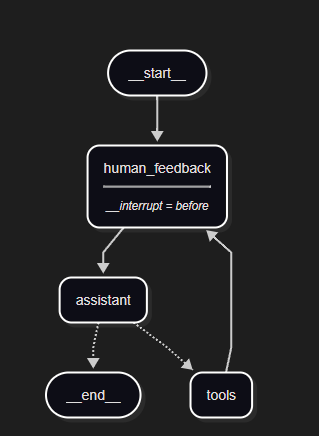

In [25]:
initial_input = {"messages": "Who is Sam Altman?"}

thread_id = {"configurable" : {"thread_id":"1"}}

for event in graph.stream(initial_input, thread_id,stream_mode="values"):
    event['messages'][-1].pretty_print()

user_input = input("Tell me are you sure?")

graph.update_state(thread_id,{"messages":user_input},as_node="human_feedback")

for event in graph.stream(None, thread_id,stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Who is Sam Altman?
================================ Human Message =================================

Who is elon musk?
================================== Ai Message ==================================

For the question "Who is Sam Altman?", I will call the wikipedia function with the argument "Sam Altman".
Tool Calls:
  wikipedia (ee298058-13ff-4b92-951e-b9809dd12838)
 Call ID: ee298058-13ff-4b92-951e-b9809dd12838
  Args:
    query: Sam Altman
  wikipedia (27d26889-0372-45c3-b8f0-42e2d315a26d)
 Call ID: 27d26889-0372-45c3-b8f0-42e2d315a26d
  Args:
    query: Elon Musk
================================= Tool Message =================================
Name: wikipedia

Page: Elon Musk
Summary: Elon Reeve Musk ( EE-lon; born June 28, 1971) is a businessman and entrepreneur known for his leadership of Tesla, SpaceX, X, and xAI. Musk has been the wealthiest person in the world since 2021; as of December 2025, Forb